In [29]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

# EVAL_PREFIX = '250426_lock_in'
# EVAL_PREFIX = '250426_cs294'
# EVAL_PREFIX = '250518_simple_ablation'
# EVAL_PREFIX = '250527-spg1-more'
# EVAL_PREFIX = '250523-final-error'
# EVAL_PREFIX = '250711-folde-testset-wCL'
# EVAL_PREFIX = '250713-naturalness-param-scan'
# EVAL_PREFIX = '250716-mse-to-bt'
# EVAL_PREFIX = '250717-spg1-ablation'
# EVAL_PREFIX = '250718-train-ablation'
# EVAL_PREFIX = '250718-spg1-olson-2014-flip'
# EVAL_PREFIX = '250720-embedding-param-scan'
EVAL_PREFIX = '250720-flip-aav'
# EVAL_PREFIX = '250721-explore-vs-exploit-RERUN'
# OTHER_EVAL_PREFIXES = ['250518_simple_ablation']
OTHER_EVAL_PREFIXES = []

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    EVAL_PREFIX,
    OTHER_EVAL_PREFIXES
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'FLIP-AAV'}


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23163/225780334.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23163/225780334.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23163/225780334.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23163/225780334.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_x

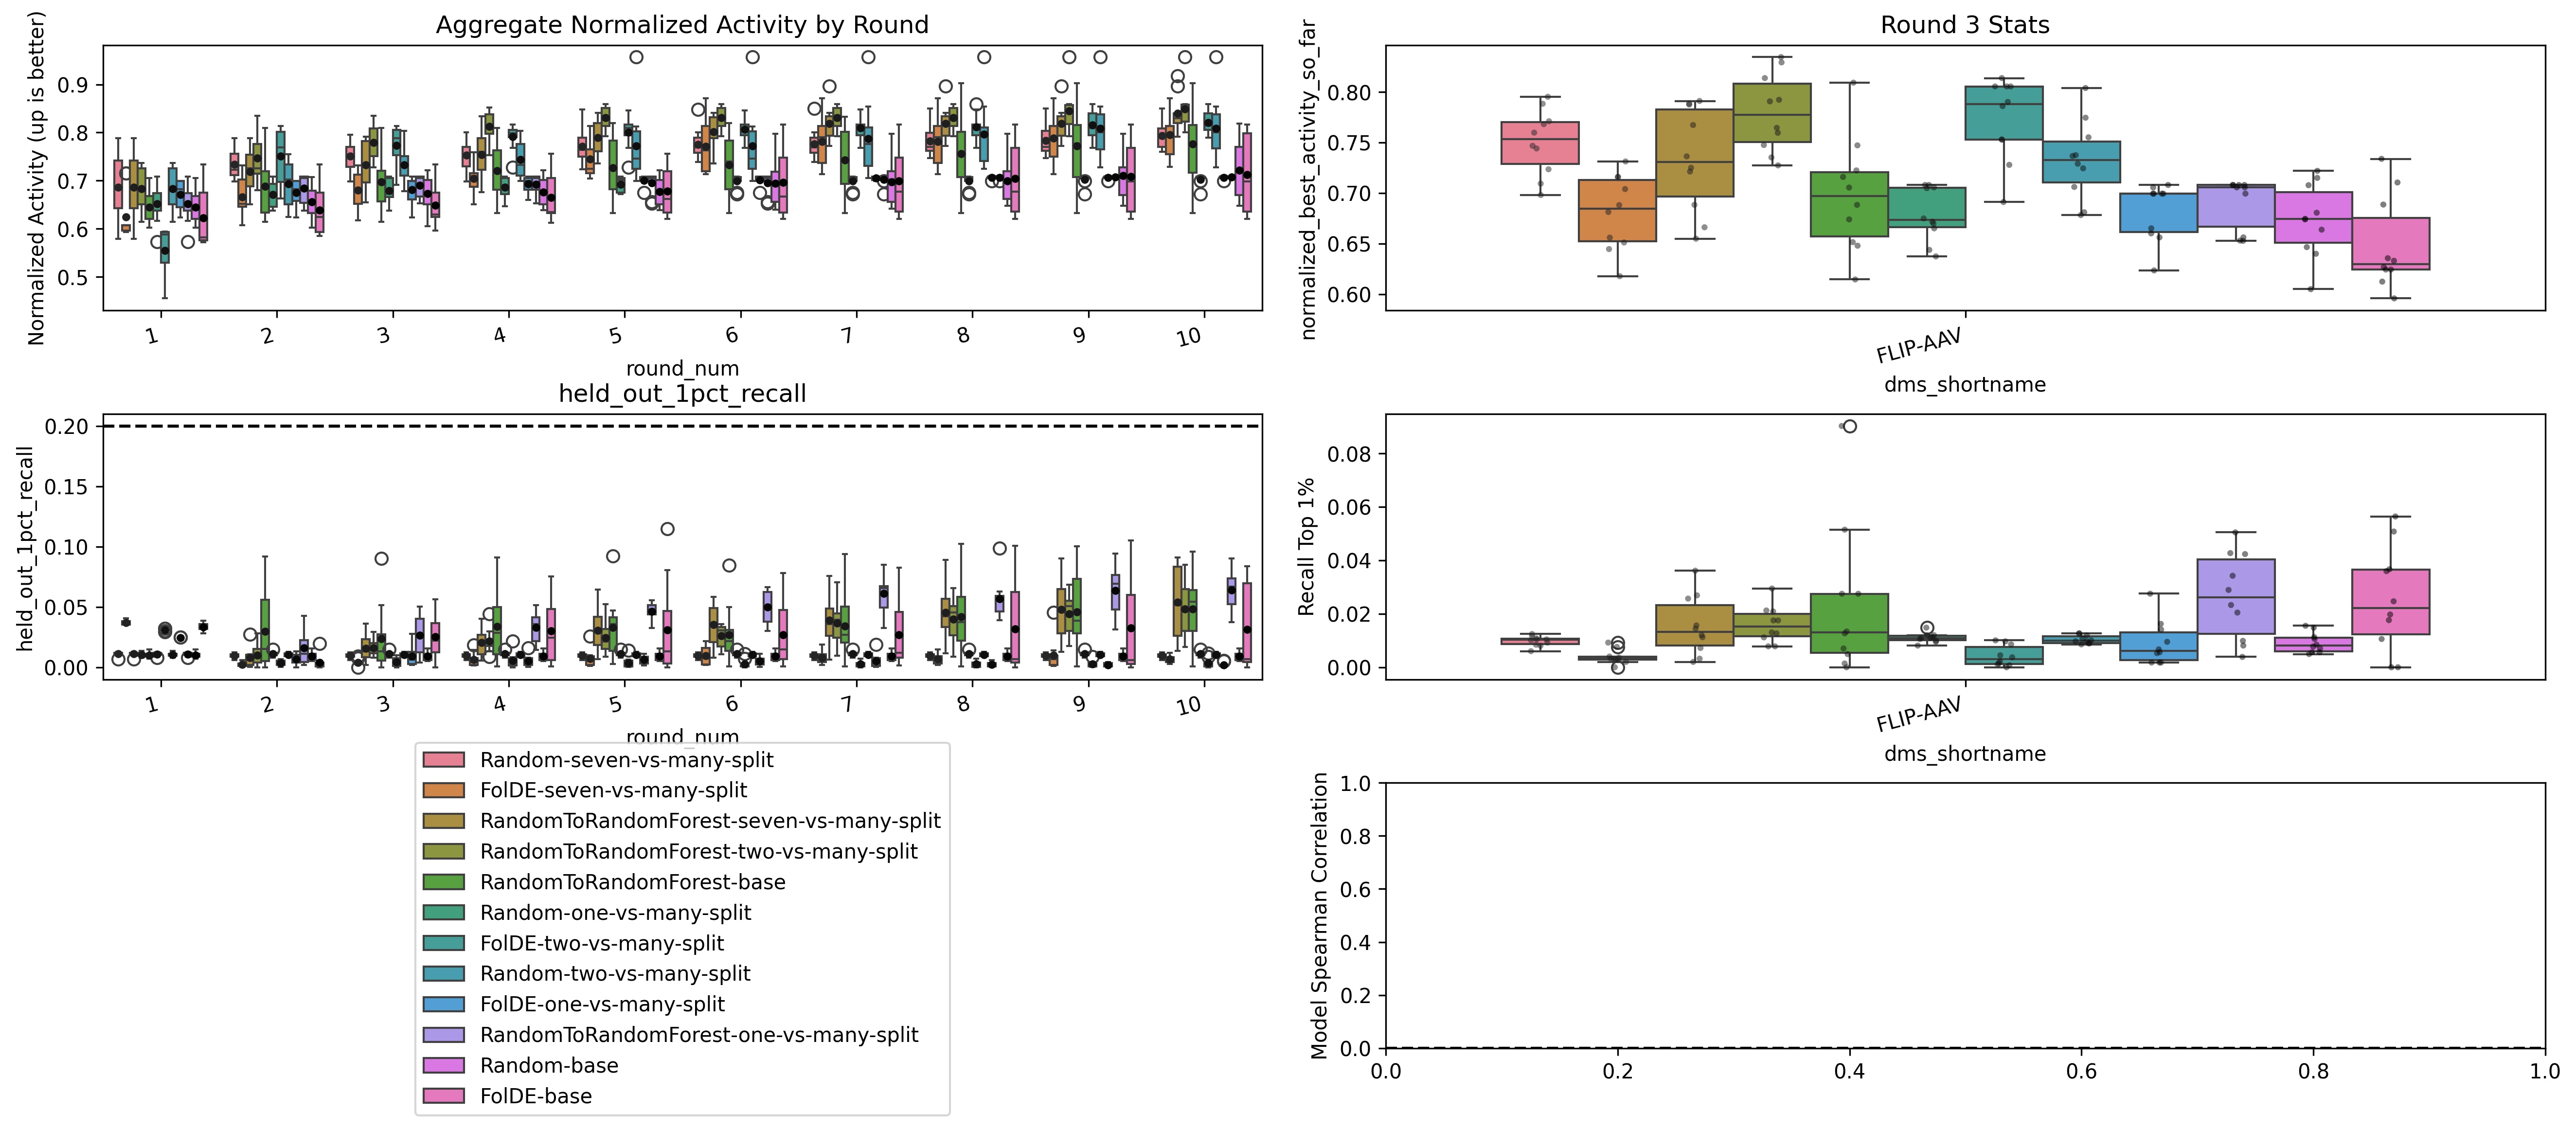

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

import json


ROUND = 3
HELD_OUT_STAT = "held_out_1pct_recall"

plotting_df = round_metrics_df.copy()
plotting_df["dms_shortname"] = plotting_df.dms_id.apply(lambda x: DMS_SHORTNAMES.get(x, x))
plotting_df["config_name"] = plotting_df.config_name.apply(
    lambda x: "EvolvePro (ESMC300M)" if x == "EvolvePro" else x
)

plotting_df["inv_best_percentile_so_far"] = plotting_df.best_percentile_so_far.apply(
    lambda x: 1.0 - x
)
single_round_df = plotting_df[plotting_df.round_num == ROUND]


def plot_metric_panel(
    ax,
    df,
    y_column,
    x_column="dms_shortname",
    hue_column="config_name",
    legend=False,
    plot_points=True,
    group_by_campaign=False,
    color_grey=False,
):
    x_order = df[x_column].unique()
    hue_order = df[hue_column].unique()

    # Create boxplot
    extra_args = {}
    if color_grey:
        extra_args["color"] = "#D3D3D3"
    bp = sns.boxplot(
        data=df,
        x=x_column,
        y=y_column,
        hue=hue_column,
        ax=ax,
        legend=legend,
        order=x_order,
        hue_order=hue_order,
        **extra_args,
    )

    if color_grey:
        # Make all box elements light grey
        plt.setp(bp.artists, edgecolor="#D3D3D3")
        plt.setp(bp.lines, color="#D3D3D3")

    if plot_points:
        # Overlay stripplot with black dots
        strip_df = None
        size = None
        alpha = None
        if group_by_campaign:
            strip_df = (
                df.groupby(["dms_shortname", "config_name", "round_num"])[y_column]
                .mean()
                .reset_index()
            )
            size = 4
            alpha = 1
        else:
            strip_df = df
            size = 3
            alpha = 0.5
        sns.stripplot(
            data=strip_df,
            x=x_column,
            y=y_column,
            hue=hue_column,
            dodge=True,
            alpha=alpha,
            ax=ax,
            size=size,
            color="black",
            legend=False,
            order=x_order,
            hue_order=hue_order,
        )

    # Style the plot
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    if legend:
        ax.legend(bbox_to_anchor=(0.5, -0.2), loc="upper center")


# Set up the figure with three subplots

fig = plt.figure(figsize=(18, 8), dpi=300)
gs = gridspec.GridSpec(6, 2, width_ratios=[1, 1])  # 3 rows, 2 columns

# Left column: One plot spanning all 3 rows
left_activity_ax = fig.add_subplot(gs[0:2, 0])
left_bottom_ax = fig.add_subplot(gs[2:4, 0])
ax2 = fig.add_subplot(gs[0:2, 1])
ax3 = fig.add_subplot(gs[2:4, 1])
ax4 = fig.add_subplot(gs[4:6, 1])
fig.tight_layout(pad=3.0)


# Middle panel: best_percentile_so_far
# plot_metric_panel(ax, plotting_df, 'inv_best_percentile_so_far', x_column='round_num', legend=True)
# ax1.set_title(f'Aggregate Normalized Rank (Round {ROUND})')
# ax.set_yscale('log')
# ax1.set_ylabel('Normalized Rank (up is better)')
plot_metric_panel(
    left_activity_ax,
    plotting_df,
    "normalized_best_activity_so_far",
    x_column="round_num",
    legend=False,
    group_by_campaign=True,
)
left_activity_ax.set_title(f"Aggregate Normalized Activity by Round")
left_activity_ax.set_ylabel("Normalized Activity (up is better)")

# {'held_out_activity_spearman': -0.014089314320311018,
#  'held_out_1pct_recall': 0.0,
#  'held_out_1pct_auc': 0.5961344295398817,
#  'held_out_10pct_recall': 0.08974358974358974,
#  'held_out_10pct_auc': 0.4942640256776383}
# plot_metric_panel(
#     left_bottom_ax,
#     plotting_df,
#     "held_out_10pct_recall",
#     x_column="round_num",
#     legend=False,
#     plot_points=False,
#     color_grey=True,
# )
left_bottom_ax.axhline(0.2, linestyle="--", color="k")
plot_metric_panel(
    left_bottom_ax,
    plotting_df,
    HELD_OUT_STAT,
    x_column="round_num",
    legend=True,
    group_by_campaign=True,
)
left_bottom_ax.set_title(HELD_OUT_STAT)
left_bottom_ax.set_ylabel(HELD_OUT_STAT)

# Top panel: best_activity_so_far
# plot_metric_panel(ax2, single_round_df, 'best_activity_so_far', legend=False)
plot_metric_panel(ax2, single_round_df, "normalized_best_activity_so_far", legend=False)
ax2.set_title(f"Round {ROUND} Stats")
# ax2.set_ylim(0, 1)

# Middle panel: best_percentile_so_far
plot_metric_panel(ax3, single_round_df, HELD_OUT_STAT, legend=False)
# ax2.set_ylim(0.95, 1.0)
if HELD_OUT_STAT == 'held_out_1pct_recall':
    ax3.set_ylabel("Recall Top 1%")
else:
    ax3.set_ylabel(HELD_OUT_STAT)
# ax3.set_yscale("log")
# ax3.set_ylim(ax3.get_ylim()[::-1])  # This flips the axis


# Bottom panel: model_spearman
# plot_metric_panel(ax4, single_round_df, "model_spearman", legend=False)
ax4.set_ylabel(f"Model Spearman Correlation")
ax4.axhline(0.0, linestyle="--", color="k")


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

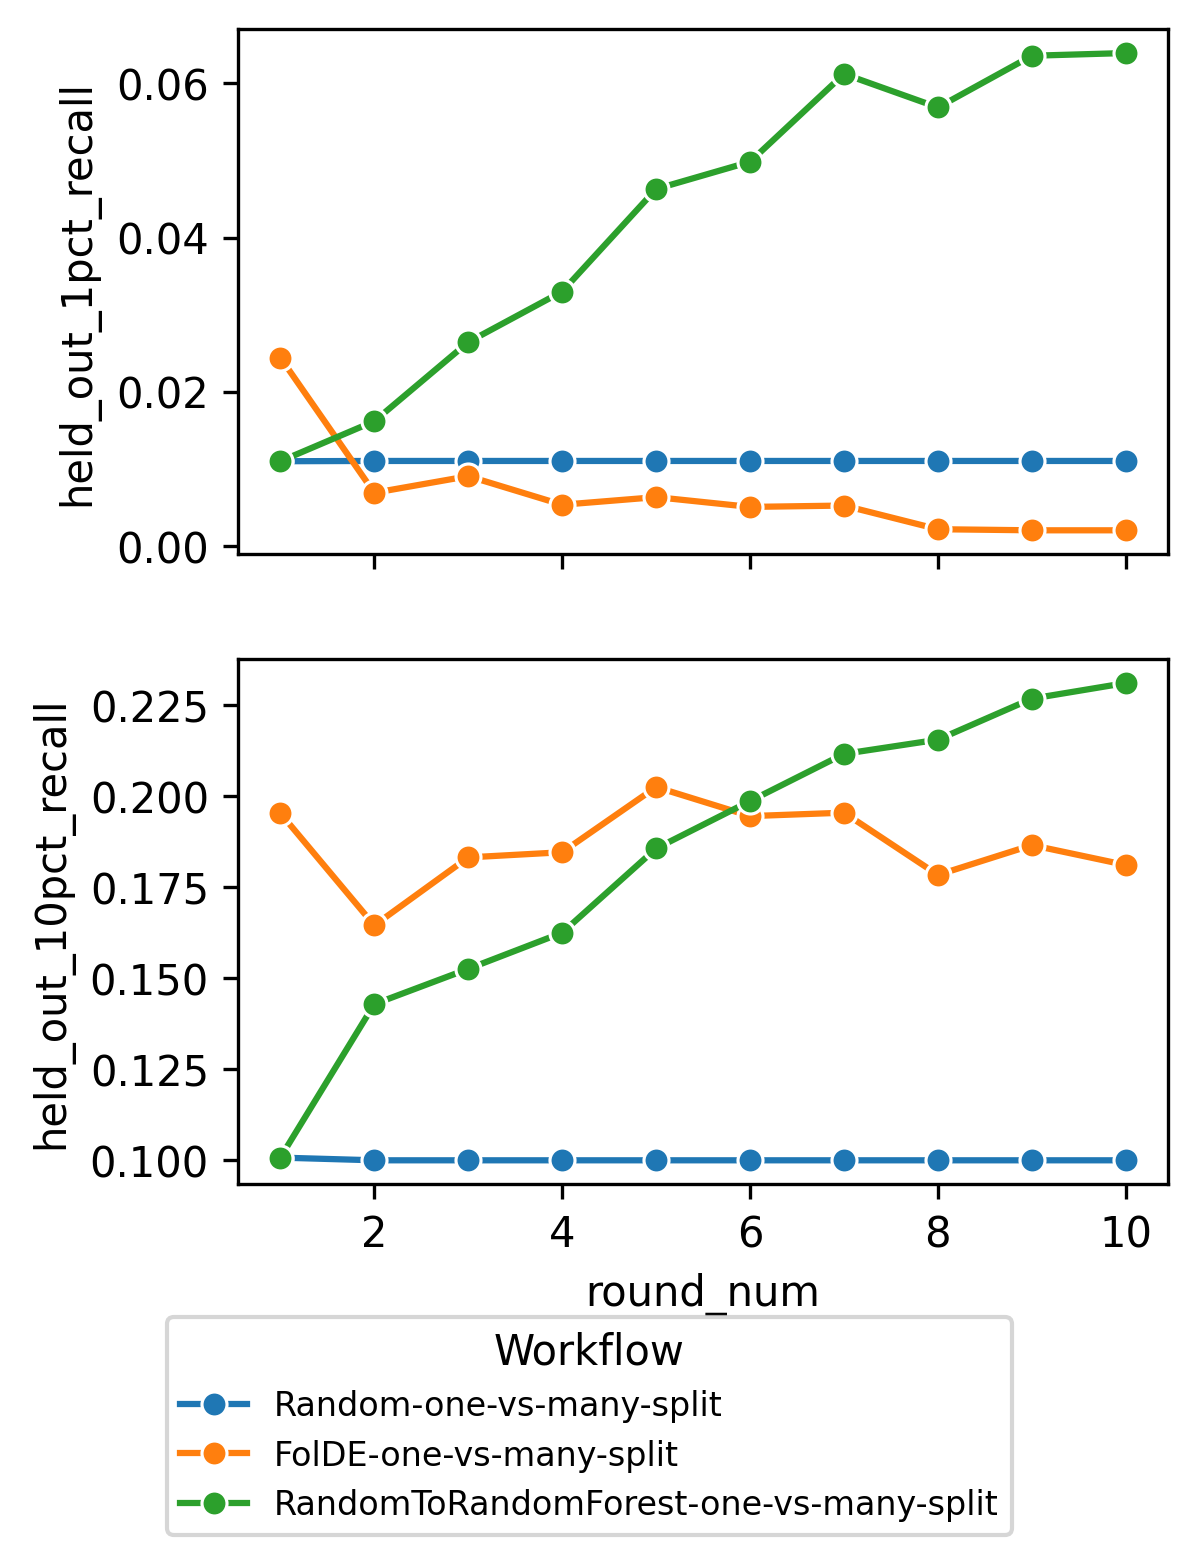

In [32]:

import re

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 5), sharex=True, dpi=300)

CONFIGS = [c for c in round_metrics_df.config_name.unique()]
# CONFIGS = ['FolDE-base','FolDE-random', 'FolDE-Random-RandomForestCtrl-15b']
# CONFIGS = ['FolDE_base','FolDE_random', 'FolDE_RandomForestFewShotModel']

# CONFIGS = [c for c in round_metrics_df.config_name.unique() if ('base' in c or '-sp-' in c)]# or 'no-naturalnessTraining' in c)]
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIGS)].copy()
plot_df['workflow'] = plot_df.config_name.apply(lambda x: x.split('-')[0])
plot_df['benchmark'] = plot_df.config_name.apply(lambda x: '-'.join(x.split('-')[1:]))

for ax, metric in zip([ax1, ax2], ['held_out_1pct_recall', 'held_out_10pct_recall']):
    sns.lineplot(
        ax=ax,
        data=plot_df[plot_df.benchmark == 'one-vs-many-split'],
        # y='held_out_activity_spearman',
        y=metric,
        # y='held_out_1pct_auc',
        # y='held_out_activity_spearman',
        x='round_num',
        hue='config_name',
        # hue='benchmark',
        errorbar=None,
        marker='o',
        # style='config_name',
        # errorbar=None
    )

# Disable ax1 legend
ax1.get_legend().remove()
ax2.legend(
    title='Workflow',
    loc='lower right',
    bbox_to_anchor=(0.85, -0.7),
    fontsize=8
)


# Compare Two Methods

ValueError: Missing x value(s) `"MLP-BT"` in config_name (specified in `order`)

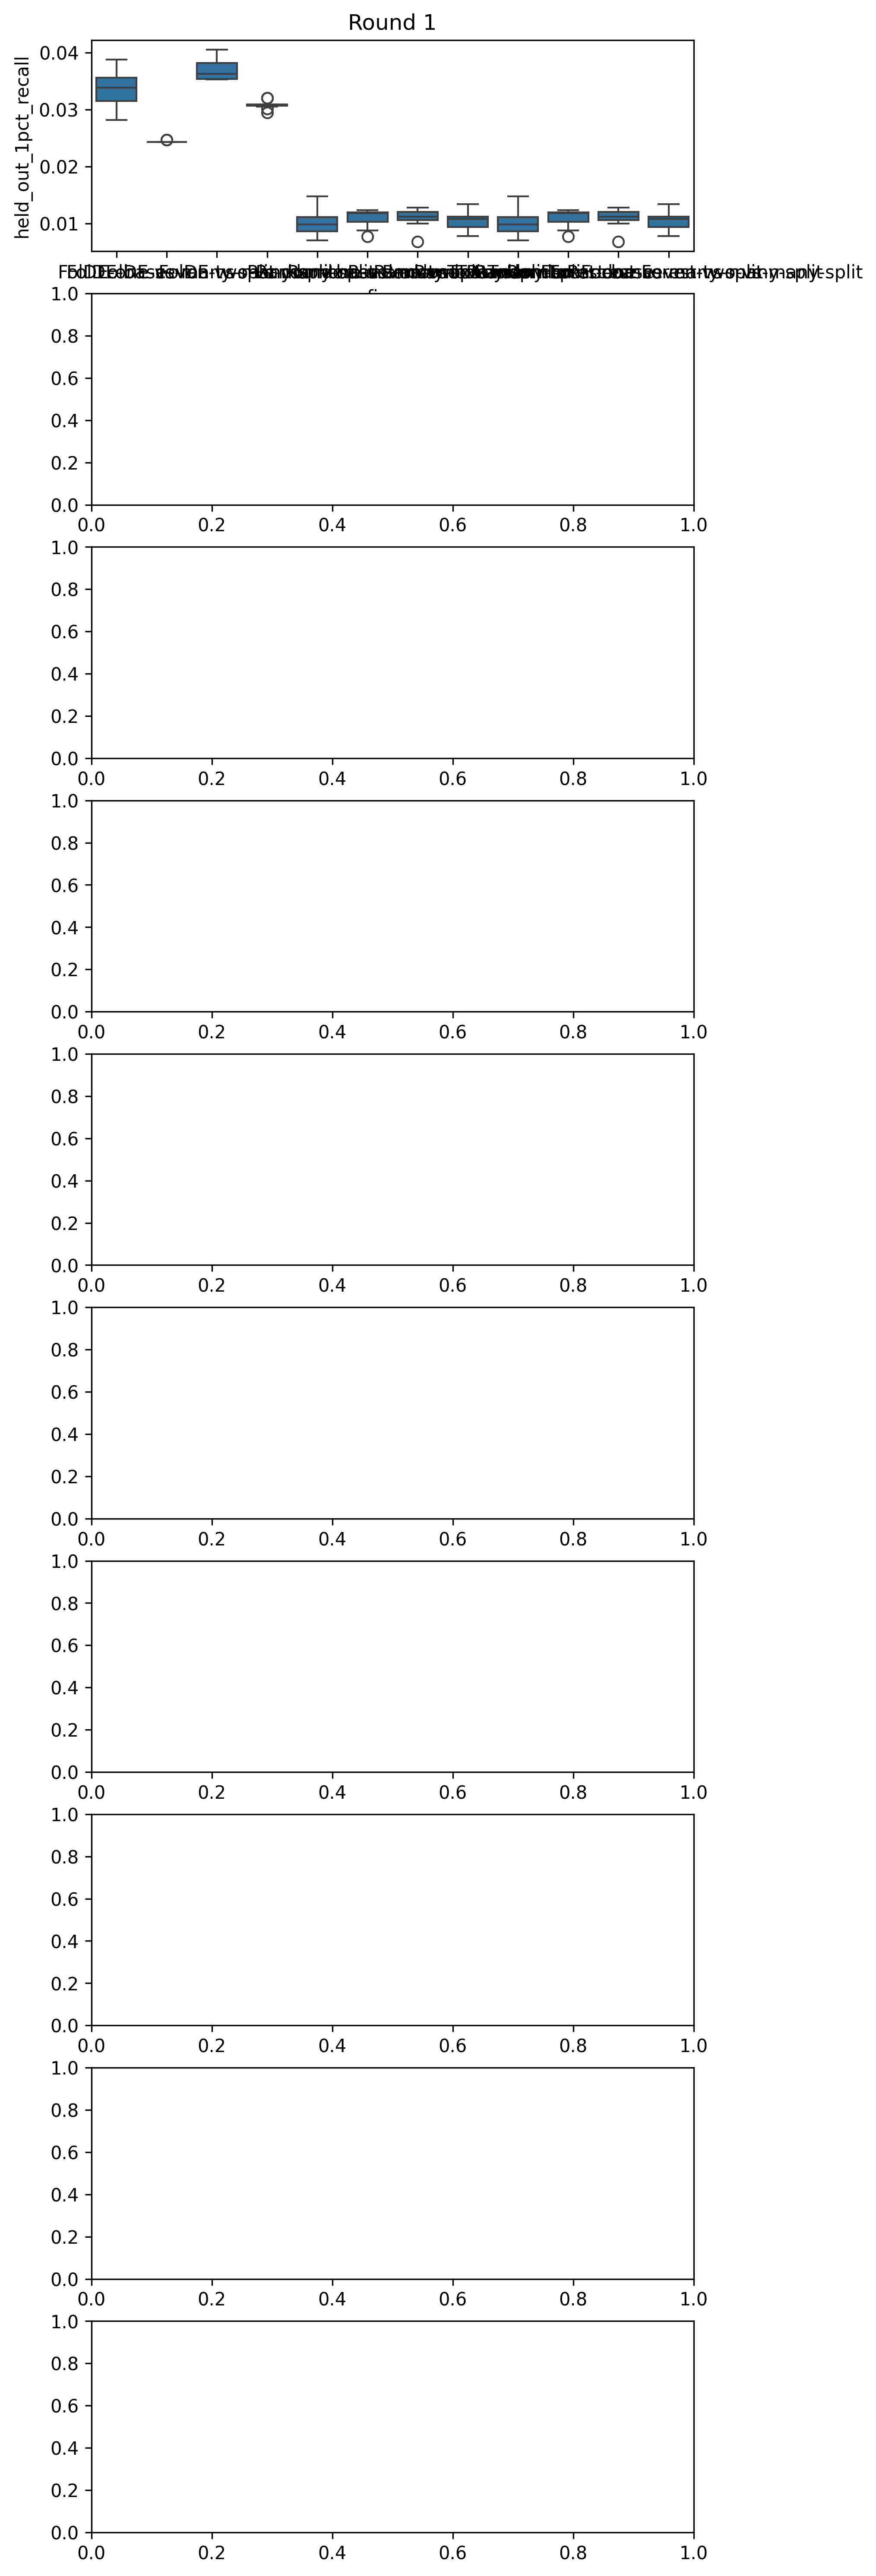

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

# CONFIG_BASE = 'FolDE-base'
CONFIG_BASE = 'MLP-BT'
METRIC = 'held_out_1pct_recall'  # 'best_activity_this_round' # 'held_out_1pct_recall' held_out_activity_spearman


comparison_df = plotting_df.sort_values(['dms_id', 'config_name', 'sim_num'])

# Sort dms_shortname for consistent x-axis order
ordered_dms = sorted(comparison_df['dms_shortname'].unique())

ordered_rounds = sorted(comparison_df.round_num.unique())
ordered_configs = [CONFIG_BASE] + sorted([c for c in comparison_df.config_name.unique() if c != CONFIG_BASE])

fig, axs = plt.subplots(len(ordered_rounds), 1, figsize=(6, 25), dpi=300)

for ax, round_num in zip(axs, ordered_rounds):
    subset_df = comparison_df[comparison_df.round_num == round_num]
    sns.boxplot(
        data=subset_df,
        x="config_name",
        y=METRIC,
        # hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.5,
        order=ordered_configs,
        # hue_order=ordered_configs,
        ax=ax
    )
    ax.set_title(f'Round {round_num}')
    pairs = [(CONFIG_BASE, config) for config in ordered_configs if config != CONFIG_BASE]

    annot = Annotator(
        ax,
        pairs,
        data=subset_df,
        x='config_name',
        y=METRIC,
        order=ordered_configs,
        # hue="config_name",
        # hue_order=ordered_configs
    )   
    annot.configure(
        test='t-test_paired',
        line_height=0,
        text_offset=-0.1,
        verbose=2
    )  #'t-test_ind'  Mann-Whitney t-test_paired
    annot.pvalue_format.config(fontsize=6)
    annot.apply_test()
    annot.annotate(
        line_offset=0,
        line_offset_to_group=0,
    )

    # ax.set_ylim(0, 0.4)

    if round_num == ordered_rounds[-1]:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
        ax.set_xlabel('Config Name')
    else:
        # hide x ticks
        ax.set_xticks([])
        ax.set_xlabel('')
    
    ax.axhline(subset_df[subset_df.config_name == CONFIG_BASE][METRIC].median(), linestyle='--', color='k')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FolDE-base vs. FolDE-no-naturalnessTraining: t-test paired samples, P_val:3.015e-01 t=1.096e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SPG1_FolDE-base vs. SPG1_FolDE-no-naturalnessTraining: t-test paired samples, P_val:3.015e-01 t=1.096e+00


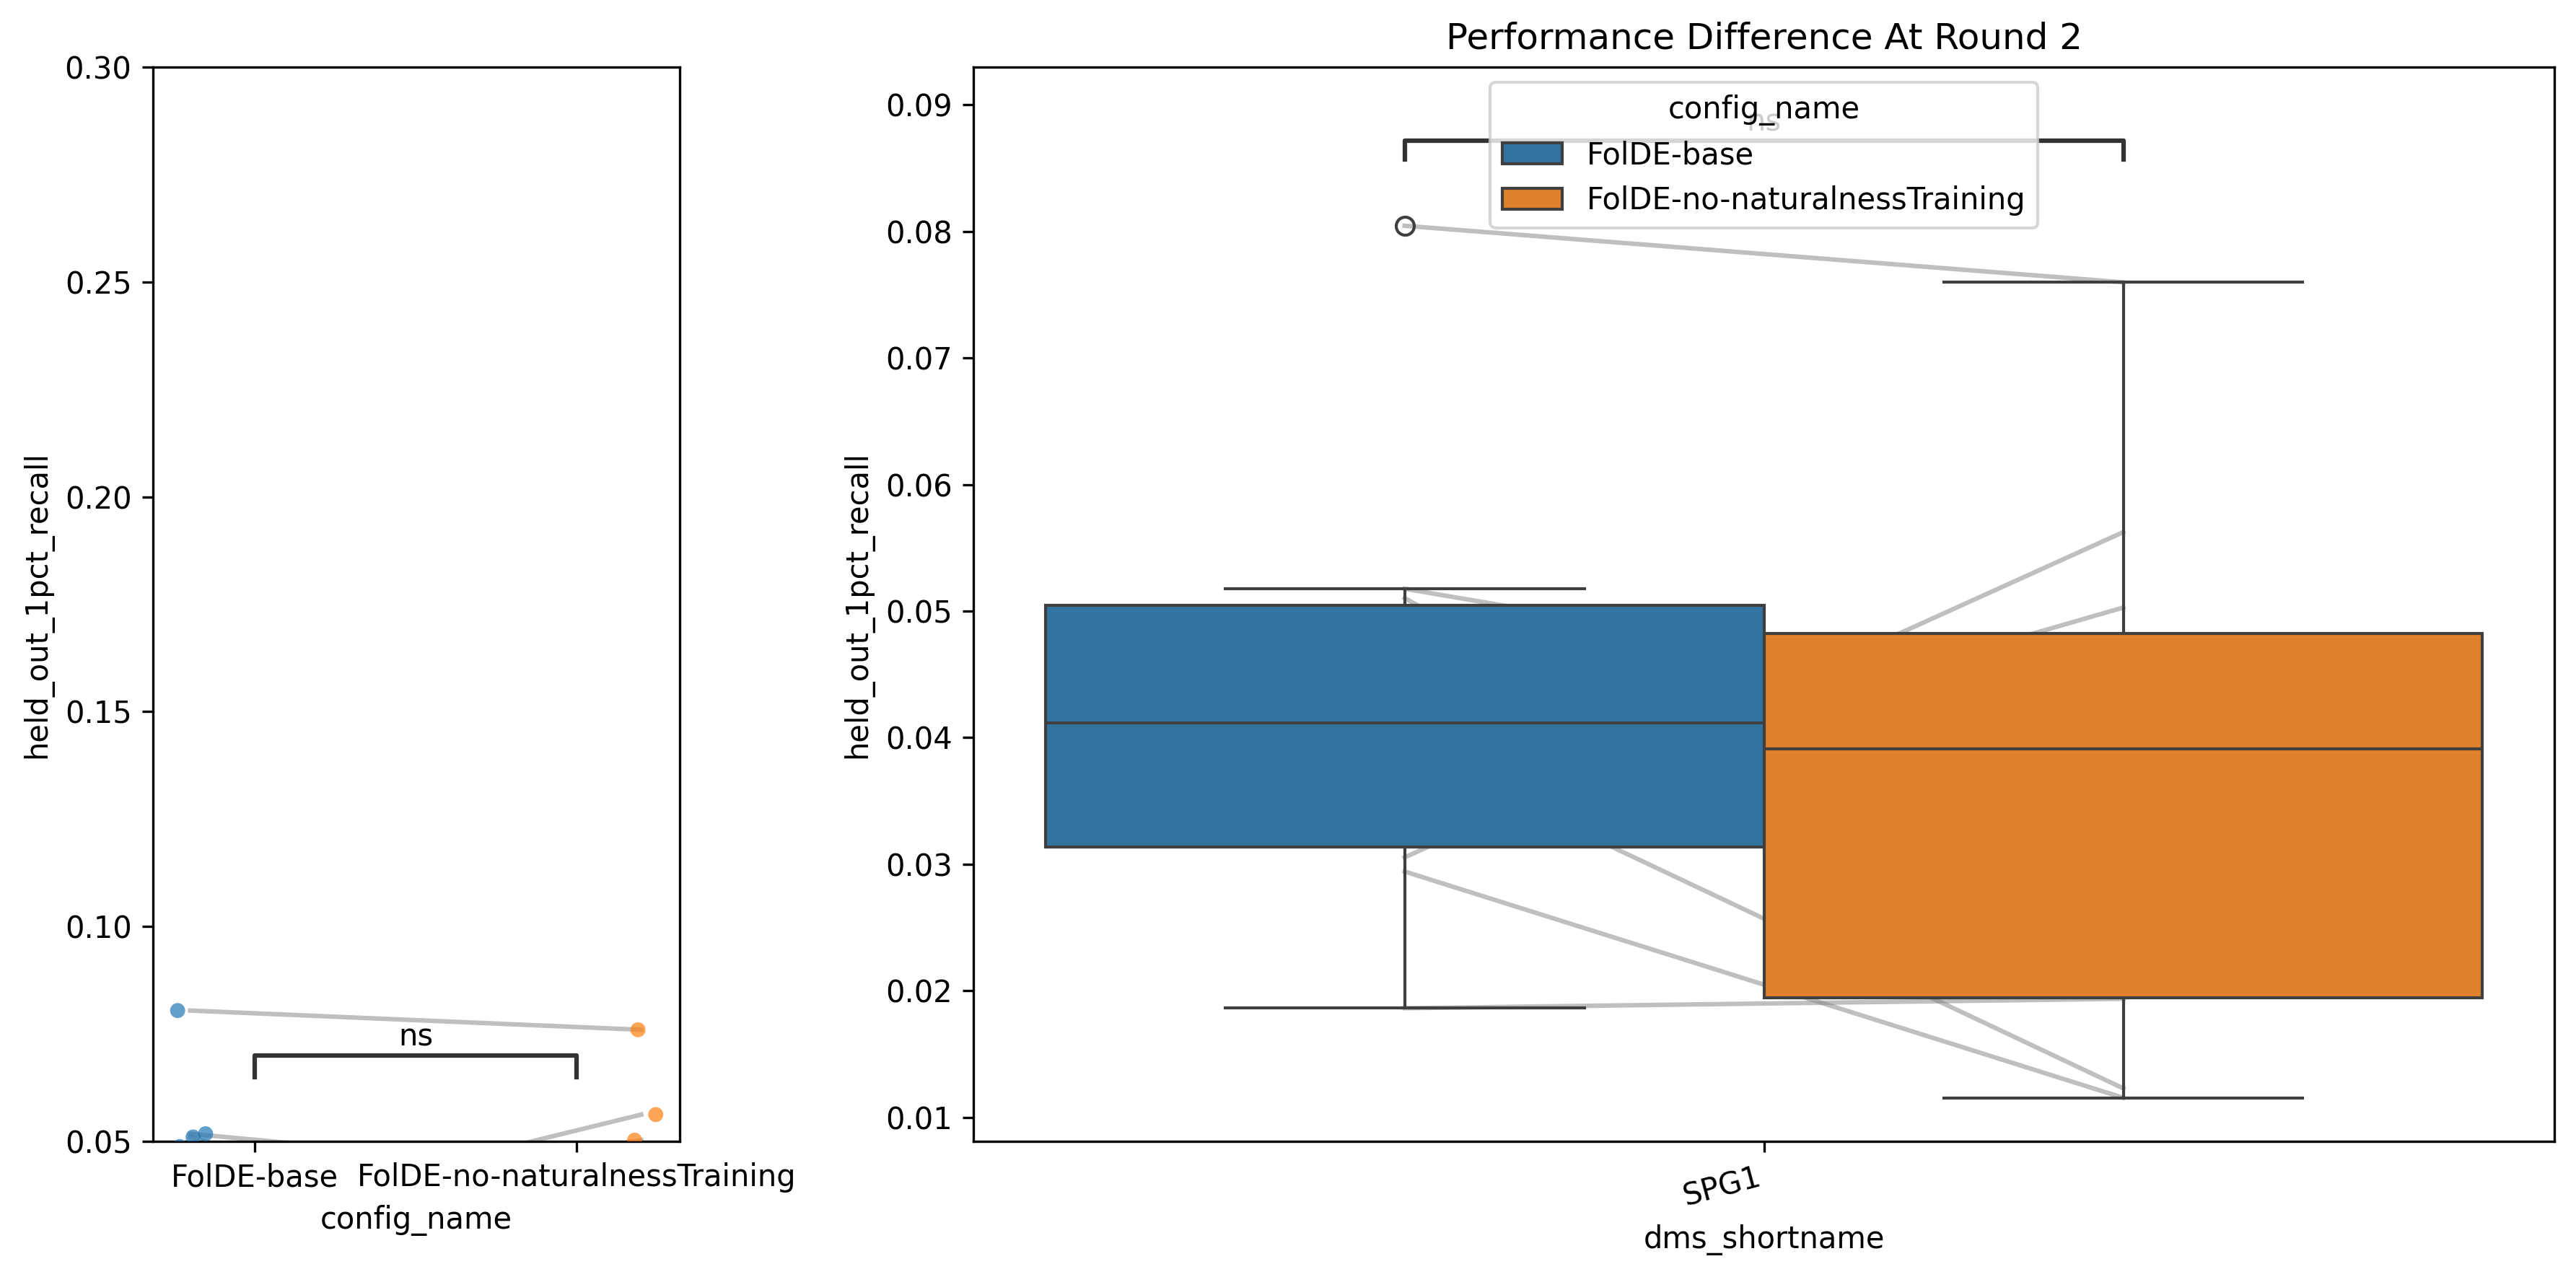

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

# method1 = 'FolDE-Random-RandomForestCtrl'
method1 = 'FolDE-base'
method2 = 'FolDE-no-naturalnessTraining'

METRIC = 'held_out_1pct_recall'  # 'best_activity_this_round'  # held_out_activity_spearman
ROUND = 2

comparison_df = plotting_df[
    plotting_df.config_name.isin([method1, method2]) & (plotting_df.round_num == ROUND)
].sort_values(['dms_id', 'config_name', 'sim_num'])

# Sort dms_shortname for consistent x-axis order
ordered_dms = sorted(comparison_df['dms_shortname'].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300, width_ratios=(1,3))

sns.stripplot(
    data=comparison_df,
    x="config_name",
    y=METRIC,
    hue="config_name",
    dodge=True,
    jitter=True,
    alpha=0.7,
    order=[method1, method2],
    hue_order=[method1, method2],
    ax=ax1
)
ax1.set_ylim(0.05, 0.3)
pairs = []
# Connect the two config points for each dms_shortname
pairs.append(
    ((method1, ), (method2, ))
)

for sim_id in comparison_df['sim_num'].unique():
    subset = comparison_df[
        (comparison_df['sim_num'] == sim_id)
    ].set_index('config_name')
    y1 = subset.loc[method1, METRIC]
    y2 = subset.loc[method2, METRIC]
    # Get the x position for this dms_shortname
    # Get the x positions for the two hues (dodge)
    offsets = [-0.2, 0.2]  # adjust if your dodge is different
    ax1.plot(
        [0 + offsets[0], 1 + offsets[1]],
        [y1, y2],
        color='gray',
        alpha=0.5,
        zorder=1
    )

annot1 = Annotator(
    ax1,
    pairs,
    data=comparison_df,
    x='config_name',
    y=METRIC,
    hue="config_name",
    hue_order=[method1, method2]
)
annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
annot1.apply_test()
annot1.annotate()


sns.boxplot(
    data=comparison_df,
    x="dms_shortname",
    y=METRIC,
    hue="config_name",
    dodge=True,
    # jitter=True,
    # alpha=0.7,
    order=ordered_dms,
    hue_order=[method1, method2],
    ax=ax2
)
# ax2.set_ylim(0.05, 0.3)

pairs = []

# Connect the two config points for each dms_shortname
for dms in ordered_dms:
    pairs.append(
        ((dms, method1), (dms, method2))
    )

    for sim_id in comparison_df['sim_num'].unique():
        subset = comparison_df[
            (comparison_df['dms_shortname'] == dms) &
            (comparison_df['sim_num'] == sim_id)
        ].set_index('config_name')
        y1 = subset.loc[method1, METRIC]
        y2 = subset.loc[method2, METRIC]
        # Get the x position for this dms_shortname
        x_pos = ordered_dms.index(dms)
        # Get the x positions for the two hues (dodge)
        offsets = [-0.2, 0.2]  # adjust if your dodge is different
        ax2.plot(
            [x_pos + offsets[0], x_pos + offsets[1]],
            [y1, y2],
            color='gray',
            alpha=0.5,
            zorder=1
        )

plt.xticks(rotation=15, ha="right")

annot = Annotator(
    ax2,
    pairs,
    data=comparison_df,
    x="dms_shortname",
    y=METRIC,
    hue="config_name",
    comparisons_correction='bonferroni',
    order=ordered_dms,
    hue_order=[method1, method2]
)
annot.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
annot.apply_test()
annot.annotate()

plt.title(f'Performance Difference At Round {ROUND}')
plt.legend(title='config_name')
plt.tight_layout()
plt.show()

# Same thing, but a list of methods

ValueError: Missing x value(s) `"FolDE", "EvolvePro", "Random"` in config_name (specified in `order`)

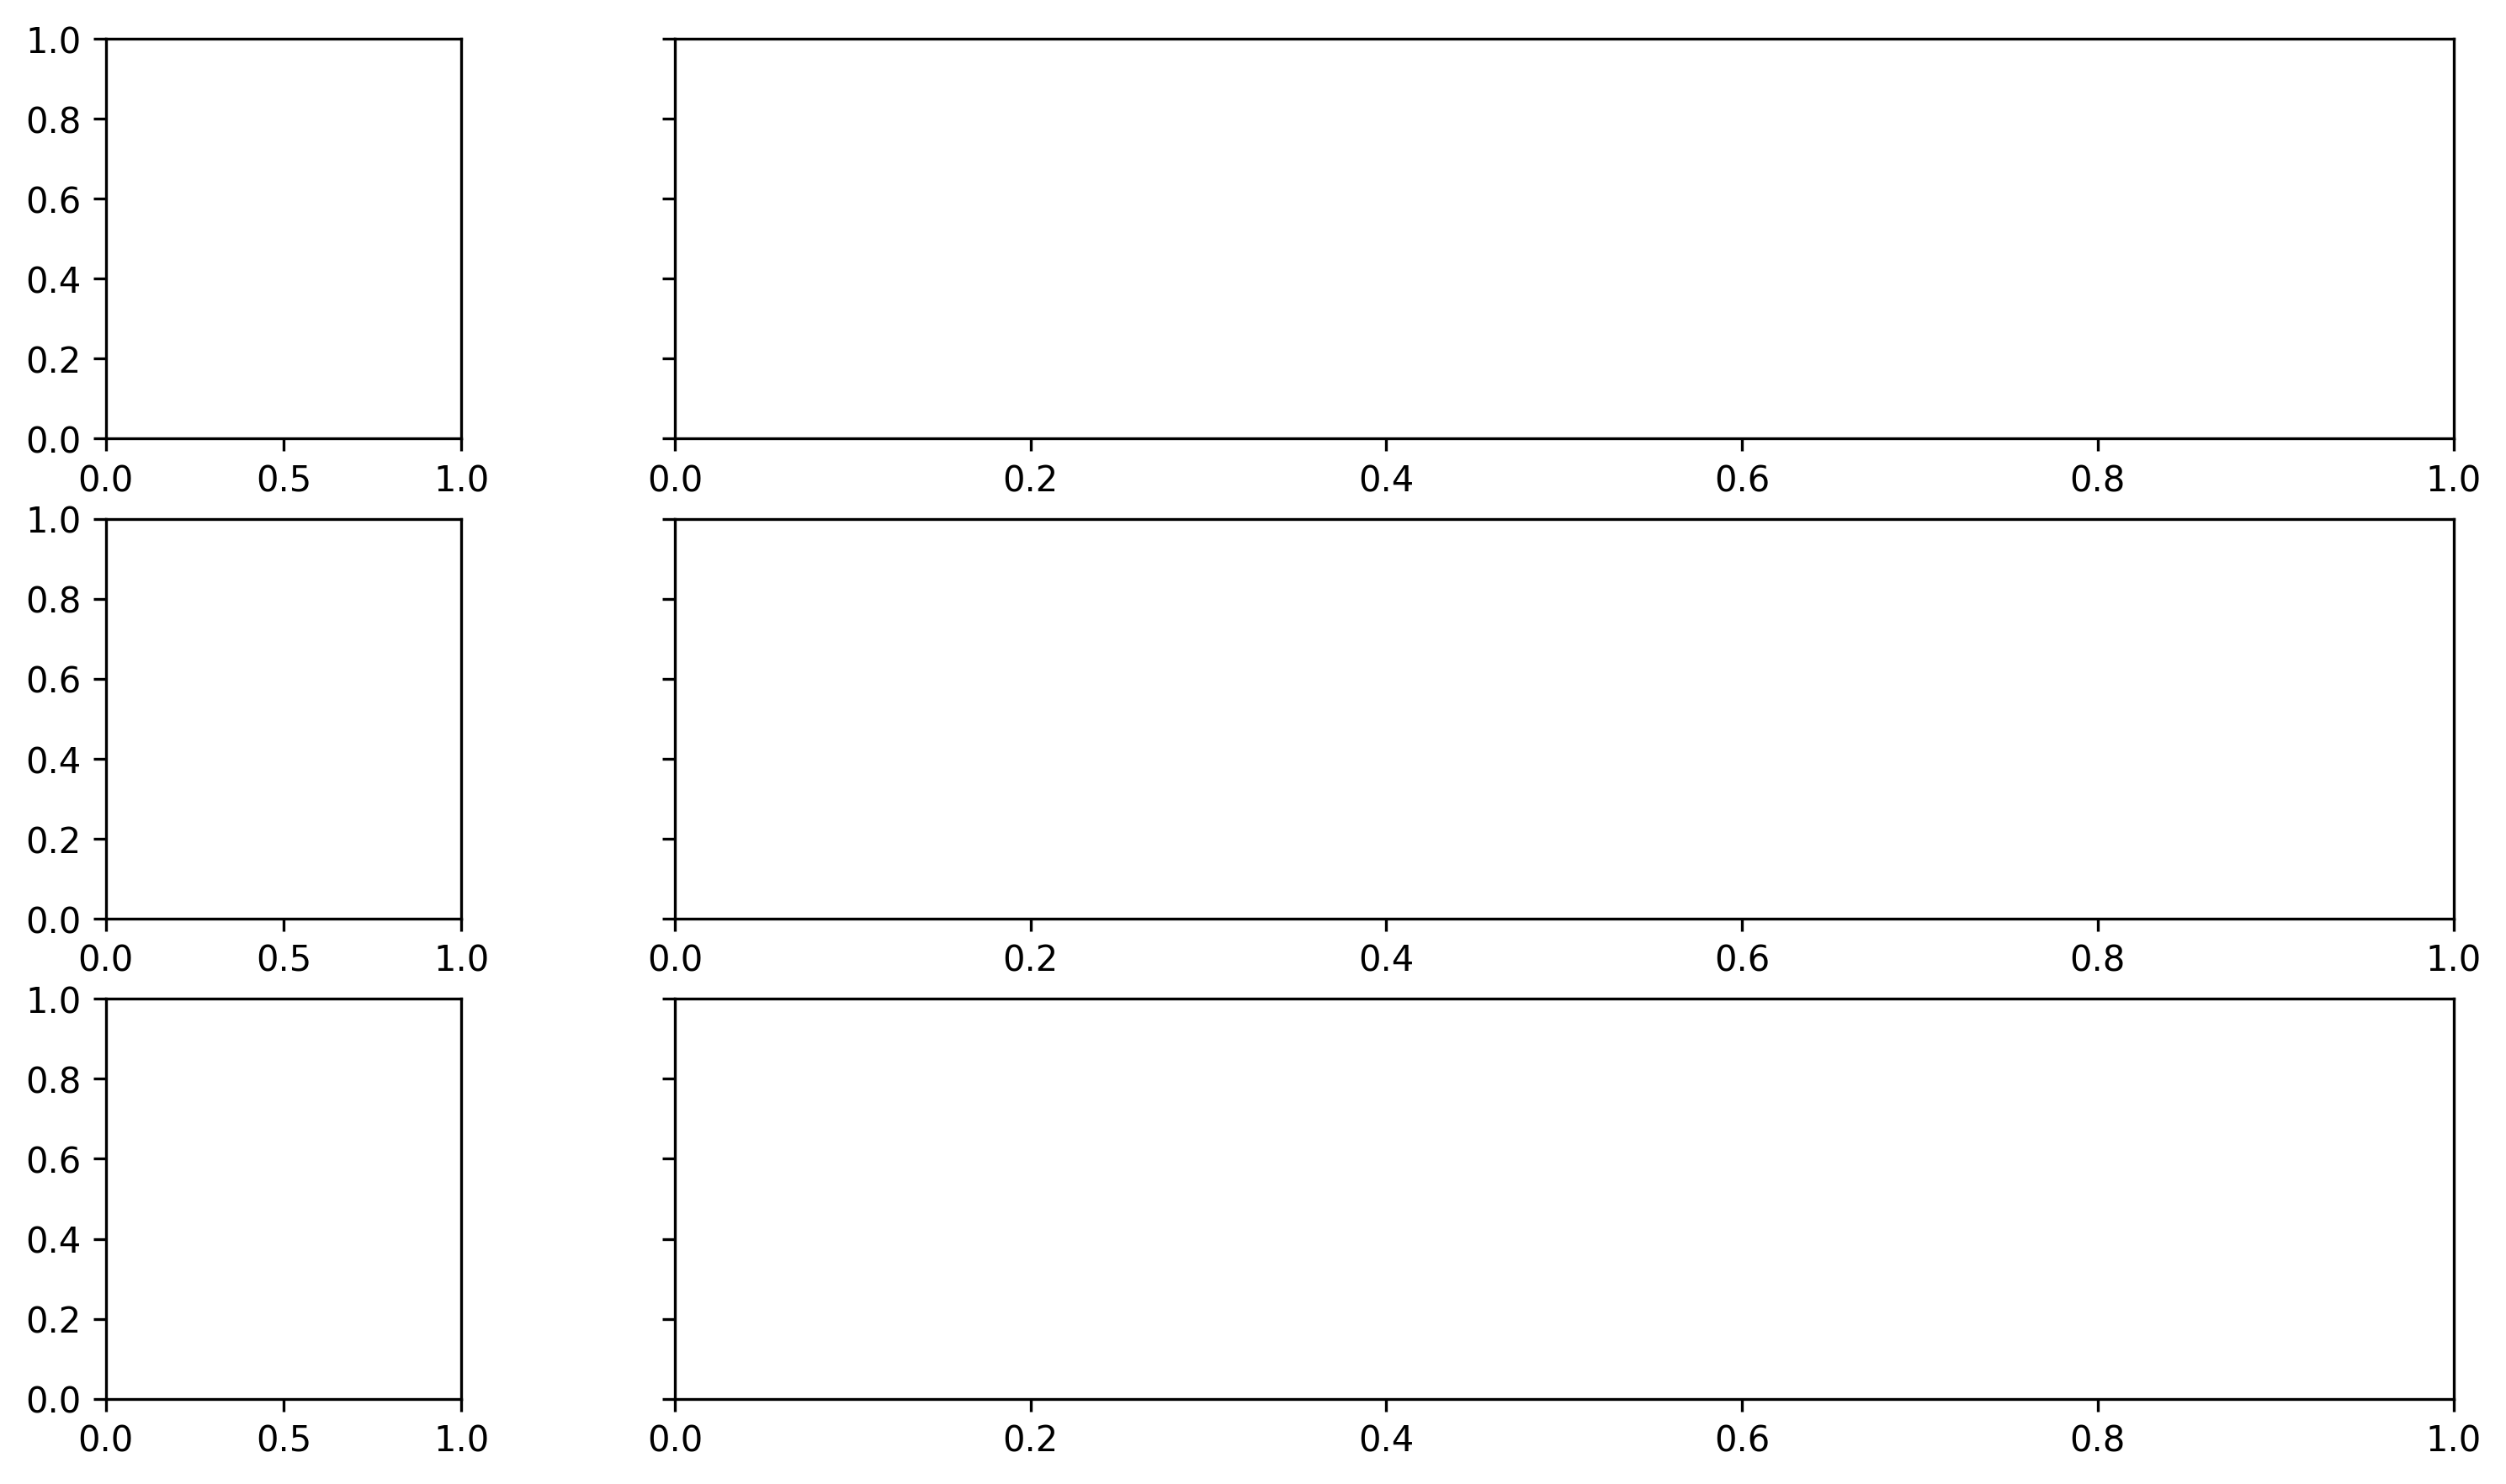

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

# method1 = 'FolDE-Random-RandomForestCtrl'
methods = [
    'Random',
    'EvolvePro',
    'FolDE'
]

METRIC = 'held_out_1pct_auc'  # 'best_activity_this_round'  # held_out_activity_spearman
LINE_ALPHA = 0.1

YRANGE = (0.0, 0.1)

def plot_aggregate_comparison(ax, data_df):
    sns.boxplot( # stripplot
        data=data_df,
        x="config_name",
        y=METRIC,
        hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=methods,
        hue_order=methods,
        ax=ax
    )

    for ii, (method1, method2) in enumerate(zip(methods[:-1], methods[1:])):
        for sim_id in data_df['sim_num'].unique():
            subset = data_df[
                (data_df['sim_num'] == sim_id)
            ].set_index('config_name')
            y1 = subset.loc[method1, METRIC]
            y2 = subset.loc[method2, METRIC]
            # Get the x position for this dms_shortname
            # Get the x positions for the two hues (dodge)
            ax.plot(
                [-0.3 + ii* 1.3, 1.0 + ii * 1.3],
                [y1, y2],
                color='gray',
                alpha=LINE_ALPHA,
                zorder=1
            )

    ax1_pairs = [
        ((mleft,), (mright,)) for mleft, mright in zip(methods[:-1], methods[1:])
    ]

    # ax1_pairs = [
    #     ((methods[0], ), (methods[1], )),
    #     ((methods[1], ), (methods[2], )),
    # ]
    annot1 = Annotator(
        ax,
        ax1_pairs,
        data=data_df,
        x='config_name',
        y=METRIC,
        hue="config_name",
        order=methods,
        hue_order=methods
    )
    annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
    annot1.apply_test()
    annot1.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')

def plot_breakdown_comparison(ax, data_df):
    sns.boxplot(
        data=data_df,
        x="dms_shortname",
        y=METRIC,
        hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=ordered_dms,
        hue_order=methods,
        ax=ax
    )

    pairs = []

    # Connect the two config points for each dms_shortname
    for dms in ordered_dms:
        for ii, (method1, method2) in enumerate(zip(methods[:-1], methods[1:])):
            pairs.append(
                ((dms, method1), (dms, method2))
            )

            for sim_id in data_df['sim_num'].unique():
                subset = data_df[
                    (data_df['dms_shortname'] == dms) &
                    (data_df['sim_num'] == sim_id)
                ].set_index('config_name')
                y1 = subset.loc[method1, METRIC]
                y2 = subset.loc[method2, METRIC]
                # Get the x position for this dms_shortname
                x_pos = ordered_dms.index(dms)
                # Get the x positions for the two hues (dodge)
                offsets = [-0.2 + ii * 0.2, 0.0 + ii * 0.2]  # adjust if your dodge is different
                ax.plot(
                    [x_pos + offsets[0], x_pos + offsets[1]],
                    [y1, y2],
                    color='gray',
                    alpha=LINE_ALPHA,
                    zorder=1
                )


    annot = Annotator(
        ax,
        pairs,
        data=data_df,
        x="dms_shortname",
        y=METRIC,
        hue="config_name",
        comparisons_correction='bonferroni',
        order=ordered_dms,
        hue_order=methods
    )
    annot.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
    annot.apply_test()
    annot.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')




fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 7), dpi=300, width_ratios=(1,5), sharey='row')

for ROUND, (leftax, rightax) in [(1, (ax1, ax2)), (2, (ax3, ax4)), (3, (ax5, ax6))]:
    comparison_df = plotting_df.copy()
    comparison_df['config_name'] = comparison_df.config_name.apply(lambda x: {
        'FolDE-random': 'Random',
        'FolDE-Random-RandomForestCtrl': 'EvolvePro',
        'FolDE-base': 'FolDE'
    }.get(x, x))
    comparison_df = comparison_df[
        comparison_df.config_name.isin(methods) & (plotting_df.round_num == ROUND)
    ].sort_values(['dms_id', 'config_name', 'sim_num']).copy()

    # Sort dms_shortname for consistent x-axis order
    ordered_dms = sorted(comparison_df['dms_shortname'].unique())

    plot_aggregate_comparison(leftax, comparison_df)
    plot_breakdown_comparison(rightax, comparison_df)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks([])
# for ax in [ax2, ax4, ax6]:
#     ax.set_yticks([])
# for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
#     ax.set_ylim(YRANGE[0], YRANGE[1])
# for ax in [ax4, ax6]:
#     ax.set_legend(False)

for ax in [ax1, ax3, ax5]:
    if METRIC == 'held_out_1pct_recall':
        ax.set_ylabel('Held Out 1% Recall')
    elif METRIC == 'held_out_10pct_recall':
        ax.set_ylabel('Held Out 10% Recall')
    else:
        ax.set_ylabel(METRIC)

ax5.set_xlabel('Workflow')
ax6.set_xlabel('ProteinGym Target')

# plt.title(f'Performance Difference At Round {ROUND}')
plt.xticks(rotation=15, ha="right")
plt.legend(title='config_name')
plt.tight_layout()
plt.show()


In [84]:
METRIC = 'held_out_10pct_recall'
# METRIC = 'held_out_activity_spearman'

comparison_df = plotting_df.copy()
comparison_df['config_name'] = comparison_df.config_name.apply(lambda x: {
    'FolDE-random': 'Random',
    'FolDE-Random-RandomForestCtrl': 'EvolvePro',
    'FolDE-base': 'FolDE'
}.get(x, x))

comparison_df = comparison_df[['dms_shortname', METRIC, 'config_name', 'round_num', 'sim_num']]\
    .groupby(['dms_shortname', 'config_name', 'round_num'])[METRIC].mean().reset_index()\
    .pivot(
        index=['dms_shortname', 'round_num'],
        columns='config_name',
        values=METRIC
    )
comparison_df = comparison_df.reorder_levels([1, 0]).sort_index()
diffs = ((comparison_df.FolDE - comparison_df.EvolvePro) / comparison_df.EvolvePro)
diffs.name = 'diff'
diffs = diffs.to_frame().reset_index()
diffs
# diffs.FolDE

,round_num,dms_shortname,diff
0,1,ADRB2_HUMAN,0.798928
1,1,AMIE_PSEAE,0.706250
2,1,CAS9_STRP1,-0.012077
3,1,KCNJ2_MOUSE,0.502874
4,1,KKA2_KLEPN,1.376000
...,...,...,...
85,6,P53_HUMAN_WT,-0.195087
86,6,PPARG_HUMAN,0.250612
87,6,PTEN_HUMAN,0.061798
88,6,S22A1_HUMAN,0.336329


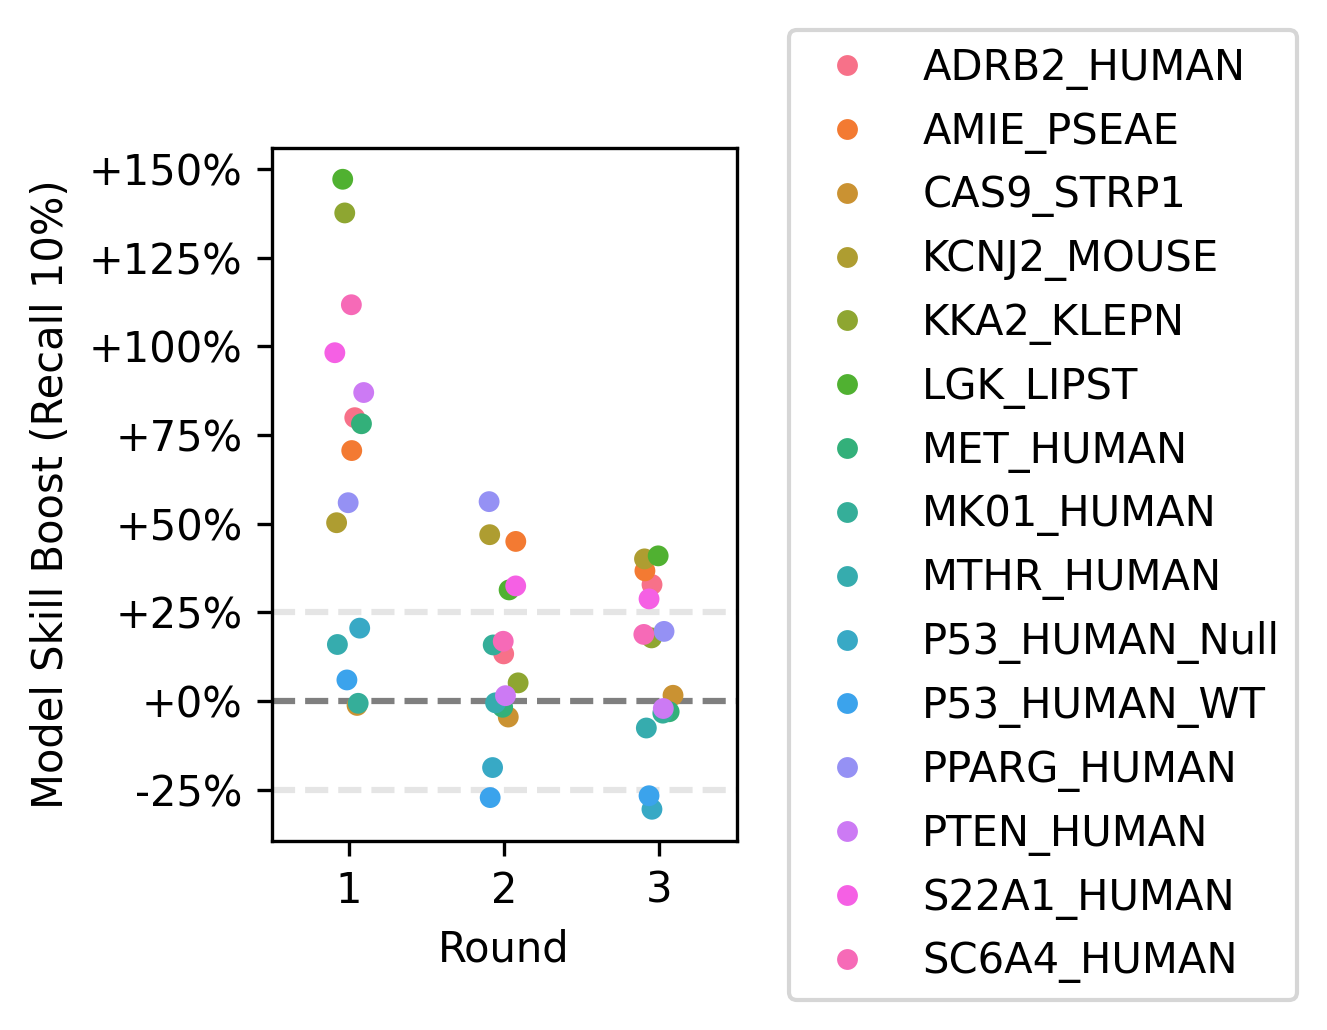

In [103]:
import matplotlib.ticker as mtick
import seaborn as sns

plt.figure(figsize=(2, 3), dpi=300)

ax = sns.stripplot(
    data=diffs[diffs.round_num <= 3],
    x='round_num',
    y='diff',
    hue='dms_shortname',
    jitter=0.1,
    # dodge=True,
    # palette='Set2',
    alpha=1.0,
    size=5,
    # linewidth=0,
)
# Custom y-axis formatter to show +25% etc.
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, _: f'{y:+.0%}')
)

# Put legend outside of plot
ax.legend(loc='upper right', bbox_to_anchor=(2.25, 1.2))
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.axhline(y=0.25, color='black', linestyle='--', alpha=0.1)
ax.axhline(y=-0.25, color='black', linestyle='--', alpha=0.1)
ax.set_xlabel('Round')
ax.set_ylabel('Model Skill Boost (Recall 10%)')
plt.savefig('notebooks/jacob/paperplots/recall_10pct_diffs.svg', format='svg')

In [ ]:
comparison_df[
    (comparison_df.round_num == 2)  
    # (comparison_df.dms_shortname == 'BLAT_ECOLX')
].groupby(['config_name', 'dms_id'])['held_out_1pct_recall'].mean()

config_name                        dms_id                          
FolDE-pairHoldout                  ANCSZ_Hobbs_2022                    0.183333
                                   BLAT_ECOLX_Firnberg_2014            0.050000
                                   CBS_HUMAN_Sun_2020                  0.016216
                                   HEM3_HUMAN_Loggerenberg_2023        0.037931
                                   HSP82_YEAST_Flynn_2019              0.052239
                                   HXK4_HUMAN_Gersing_2022_activity    0.037209
                                   OXDA_RHOTO_Vanella_2023_activity    0.031250
                                   PPM1D_HUMAN_Miller_2022             0.005000
                                   SHOC2_HUMAN_Kwon_2022               0.010909
FolDE-pairHoldout-krigingbeliever  ANCSZ_Hobbs_2022                    0.120833
                                   BLAT_ECOLX_Firnberg_2014            0.062500
                                   CBS_HUMAN_Sun_202

In [26]:
comparison_df.dms_id

1         ANCSZ_Hobbs_2022
1         ANCSZ_Hobbs_2022
1         ANCSZ_Hobbs_2022
1         ANCSZ_Hobbs_2022
1         ANCSZ_Hobbs_2022
             ...          
1    SHOC2_HUMAN_Kwon_2022
1    SHOC2_HUMAN_Kwon_2022
1    SHOC2_HUMAN_Kwon_2022
1    SHOC2_HUMAN_Kwon_2022
1    SHOC2_HUMAN_Kwon_2022
Name: dms_id, Length: 180, dtype: object

In [27]:
import scipy.stats as stats

# 1. Pivot the DataFrame to get paired values side by side
paired = comparison_df.pivot_table(
    index=['dms_id', 'sim_num'],  # or add more columns if needed for unique pairing
    columns='config_name',
    values='held_out_1pct_recall'
)

# 2. Drop any rows with missing values (i.e., where a pair is incomplete)
paired = paired.dropna(subset=[method1, method2])

# 3. Run the paired t-test
t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])
means = paired.mean(axis=0)

print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g}, means ({method1}: {means[method1]:.3f}, {method2}: {means[method2]:.3f})")

Paired t-test: t = 0.848, p = 0.399, means (FolDE-pairHoldout: 0.047, FolDE-pairHoldout-krigingbeliever: 0.043)


/var/tmp/ipykernel_2566419/2137692163.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/var/tmp/ipykernel_2566419/2137692163.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/var/tmp/ipykernel_2566419/2137692163.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


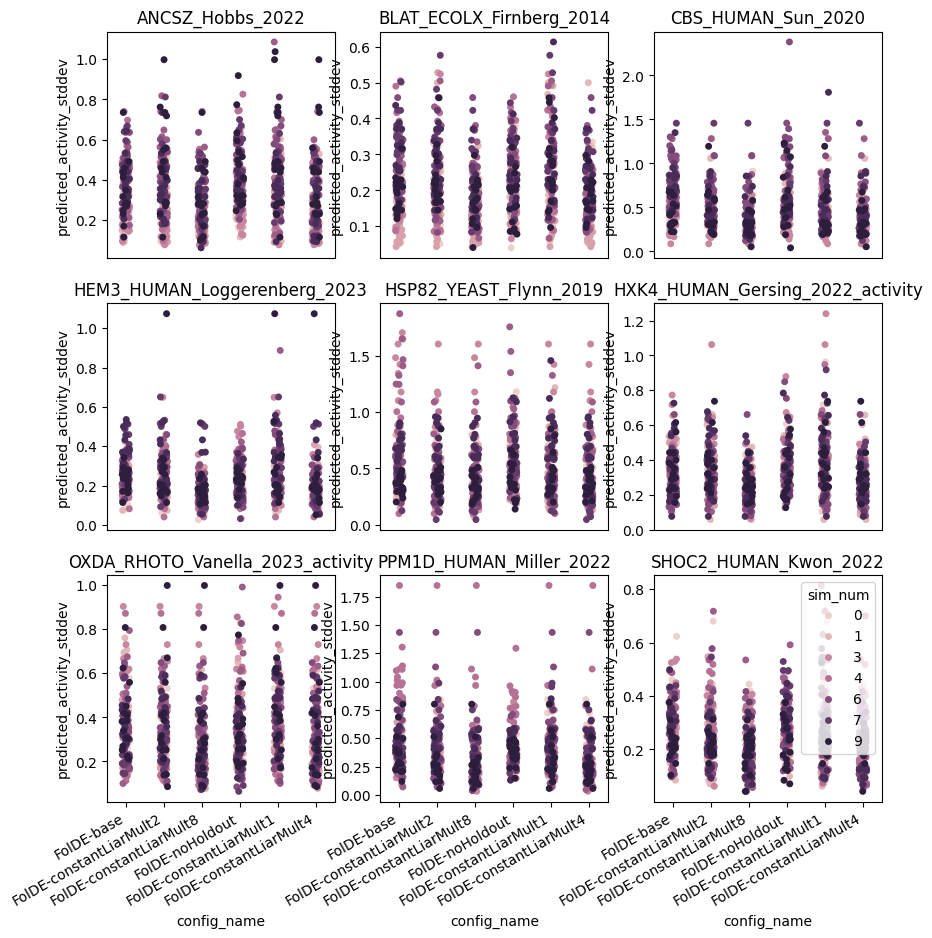

In [39]:
fig, axs = plt.subplots(3, 3, figsize=(10,10))
axs = axs.flatten()

for ii, (dms_id, ax) in enumerate(zip(mutant_df.dms_id.unique(), axs)):
    sns.stripplot(
        data=mutant_df[
            (mutant_df.dms_id == dms_id) &
            (mutant_df.round_found == 2)
        ],
        x='config_name',
        y='predicted_activity_stddev',
        ax=ax,
        hue='sim_num'
    )
    if ii > 5:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    else:
        ax.set_xticks([])
        ax.set_xlabel('')

    ax.set_title(dms_id)
    if ii != 8:
        ax.get_legend().remove()

<Axes: xlabel='predicted_activity_stddev', ylabel='activity'>

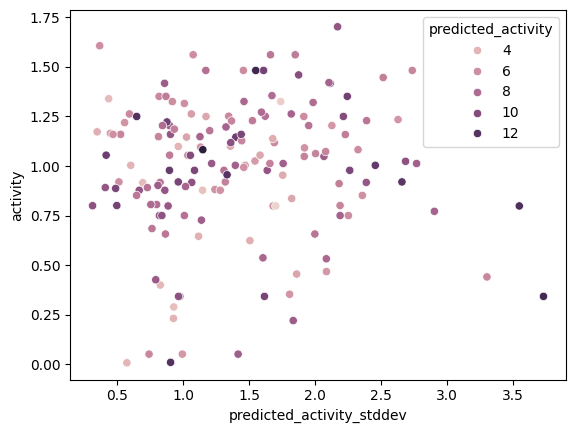

In [8]:

sns.scatterplot(
    data=mutant_df[
        (mutant_df.round_found == 2) &
        (mutant_df.dms_id == 'BLAT_ECOLX_Firnberg_2014') &
        (mutant_df.config_name == 'FolDE-holdoutPairs')
    ],
    x='predicted_activity_stddev',
    y='activity',
    hue='predicted_activity'
)

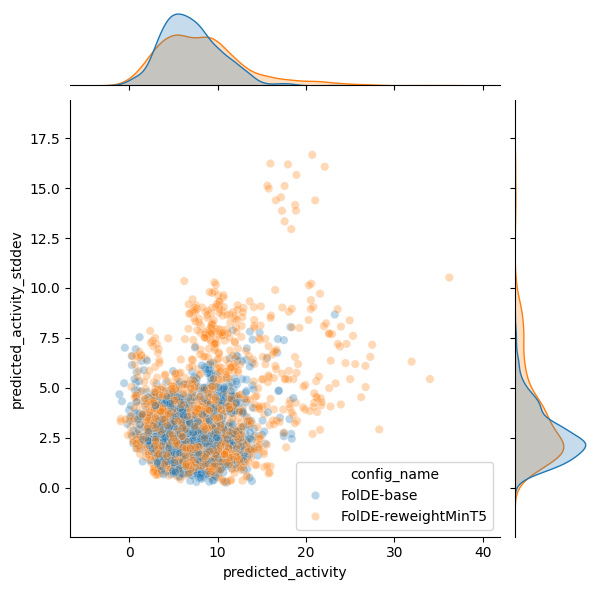

In [9]:
sns.jointplot(
    data=mutant_df[
        (mutant_df.round_found == 2) &
        # (mutant_df.dms_id == 'ANCSZ_Hobbs_2022') &
        (mutant_df.config_name.isin(['FolDE-base', 'FolDE-reweightMinT5']))
    ],
    x='predicted_activity',
    y='predicted_activity_stddev',
    hue='config_name',
    alpha=0.3
)

# Plot Training Losses

In [29]:
train_df

,loss_type,log_step,loss,model_idx,sim_idx,dms_id,config_name,epoch,dms_shortname
0,pretrain_train,0,0.572165,0,0,ANCSZ_Hobbs_2022,FolDE-base,0,ANCSZ
1,pretrain_train,1,0.344472,0,0,ANCSZ_Hobbs_2022,FolDE-base,10,ANCSZ
2,pretrain_train,2,0.276469,0,0,ANCSZ_Hobbs_2022,FolDE-base,20,ANCSZ
3,pretrain_train,3,0.222421,0,0,ANCSZ_Hobbs_2022,FolDE-base,30,ANCSZ
4,pretrain_train,4,0.195139,0,0,ANCSZ_Hobbs_2022,FolDE-base,40,ANCSZ
...,...,...,...,...,...,...,...,...,...
80,finetune_recall_1pct,16,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,160,SHOC2_HUMAN
81,finetune_recall_1pct,17,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,170,SHOC2_HUMAN
82,finetune_recall_1pct,18,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,180,SHOC2_HUMAN
83,finetune_recall_1pct,19,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,190,SHOC2_HUMAN


ANCSZ
BLAT_ECOLX
CBS_HUMAN
HEM3_HUMAN
HSP82_YEAST
HXK4_HUMAN
OXDA_RHOTO
PPM1D_HUMAN
SHOC2_HUMAN


Text(0.5, 0.98, 'Loss for FolDE-base, Round 2')

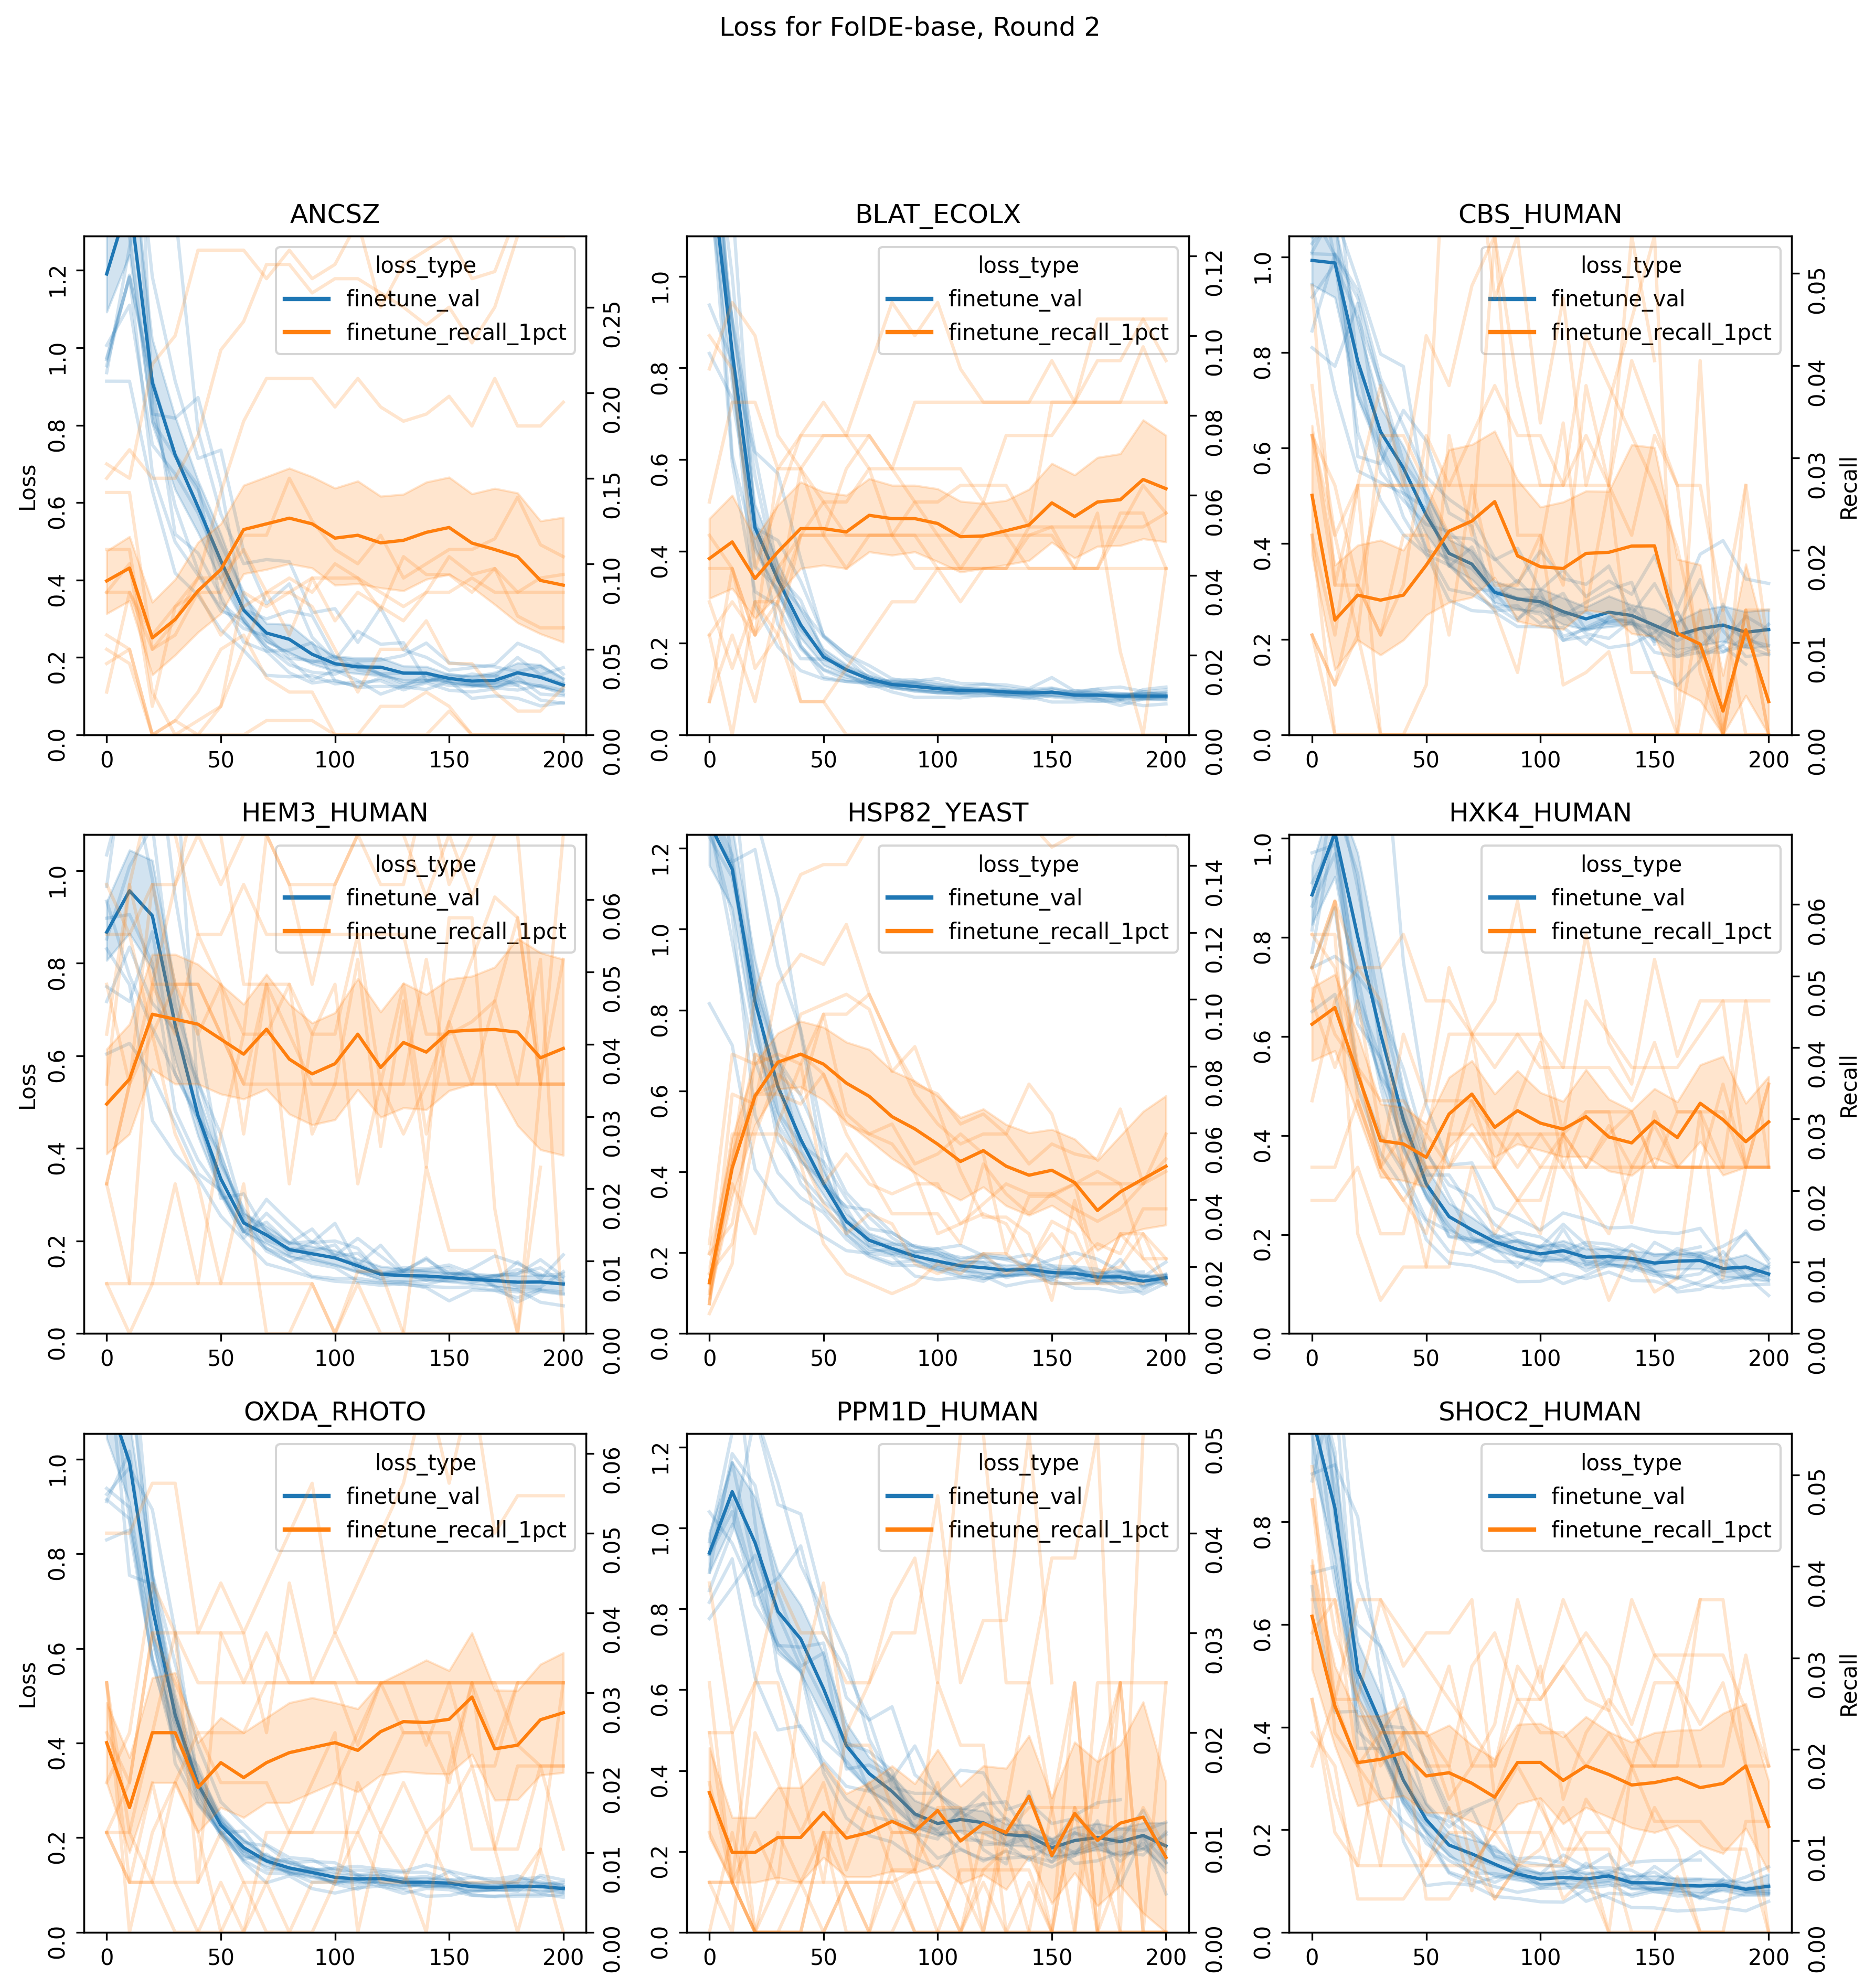

In [40]:
from folde.util import get_training_loss_df
import matplotlib.pyplot as plt

CONFIG_NAME = 'FolDE-base'
ROUND = 1

train_df = get_training_loss_df(results, ROUND)
train_df['epoch'] = train_df['log_step'] * results.campaign_results[0].config_results[0].config.few_shot_model_params['val_frequency']
train_df['dms_shortname'] = train_df['dms_id'].apply(lambda x: DMS_SHORTNAMES.get(x))

fig, axs = plt.subplots(3, 3, figsize=(14, 14), dpi=300)
axs = axs.flatten()
for ax_idx, (dms_shortname, ax) in enumerate(zip(train_df['dms_shortname'].unique(), axs)):
    print(dms_shortname)
    plot_df = train_df[
        (train_df.dms_shortname == dms_shortname) &
        (train_df.config_name == CONFIG_NAME) &
        # (train_df.loss_type.str.startswith('pretrain'))
        (train_df.loss_type.str.startswith('finetune_recall') | train_df.loss_type.str.startswith('finetune_val'))
    ]

    # Get unique loss_types and assign a color to each
    loss_types = plot_df['loss_type'].unique()
    color_map = {lt: color for lt, color in zip(loss_types, plt.cm.tab10.colors)}
    sim_idx_to_alpha_map = {}

    right_ax = ax.twinx()

    for sub_ax, plot_subset in [
        (ax, plot_df[~plot_df.loss_type.str.startswith('finetune_recall')]),
        (right_ax, plot_df[plot_df.loss_type.str.startswith('finetune_recall')]),
    ]:
        # Group by sim_idx and model_idx, but color by loss_type
        for sim_idx in plot_subset.sim_idx.unique():
            sim_plot_df = plot_subset[plot_subset.sim_idx == sim_idx].groupby(['epoch', 'loss_type']).loss.mean().reset_index()
            sns.lineplot(
                ax=sub_ax,
                data=sim_plot_df,
                y='loss',
                x='epoch',
                hue='loss_type',
                palette=color_map,
                alpha=0.2,
                errorbar=None,
                legend=False
            )

        # for (sim_idx, model_idx, loss_type), group in plot_df.groupby(['sim_idx', 'model_idx', 'loss_type']):
        #     # loss_type = group['loss_type'].iloc[0]
        #     color = color_map[loss_type]
        #     alpha = sim_idx_to_alpha_map.get(sim_idx, 0.1)
        #     sub_ax.plot(group['epoch'], group['loss'], color=color, alpha=alpha)  # alpha for visibility
        
        sns.lineplot(
            ax=sub_ax,
            data=plot_subset,
            x='epoch',
            y='loss',
            hue='loss_type',
            palette=color_map,
            legend=False
        )
        try:
            sub_ax.set_ylim(0.0, plot_subset.loss.dropna().quantile(0.95))
        except Exception as e:
            print(plot_subset.loss.dropna().quantile(0.95))
            print(plot_subset.loss.dropna().mean())
            print(plot_subset.loss.dropna().describe())
            print(e)
        sub_ax.tick_params(axis='y', labelrotation=90)
    ax.set_ylabel('Loss' if ax_idx % 3 == 0 else '')
    right_ax.set_ylabel('Recall' if ax_idx % 3 == 2 else '')


    # Optionally, add a legend for loss_type
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=color_map[lt], lw=2, label=lt) for lt in loss_types]
    ax.legend(handles=legend_elements, title='loss_type')

    dms_name = '_'.join(plot_df['dms_shortname'].unique())
    config_name = '_'.join(plot_df['config_name'].unique())
    ax.set_title(f'{dms_name}')

    ax.set_xlabel('')
    # ax.set_ylim(0, 1.0)
fig.suptitle(f'Loss for {CONFIG_NAME}, Round {ROUND+1}')


<Axes: xlabel='finetune_val', ylabel='finetune_recall_1pct'>

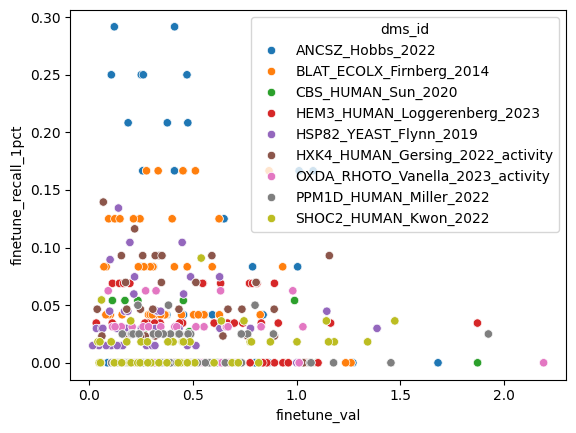

In [91]:

pivoted = train_df[train_df.epoch == 200].pivot_table(
    index=['dms_id', 'config_name', 'model_idx', 'sim_idx'],
    columns='loss_type',
    values='loss',
).reset_index()

sns.scatterplot(
    data=pivoted,
    # data=pivoted[pivoted.dms_id == 'PPM1D_HUMAN_Miller_2022'],
    x='finetune_val',
    y='finetune_recall_1pct',
    hue='dms_id'
)

In [80]:
train_df

,loss_type,log_step,loss,model_idx,sim_idx,dms_id,config_name,epoch,dms_shortname
0,pretrain_train,0,0.574605,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,0,ANCSZ
1,pretrain_train,1,0.276604,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,10,ANCSZ
2,pretrain_train,2,0.192737,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,20,ANCSZ
3,pretrain_train,3,0.161864,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,30,ANCSZ
4,pretrain_train,4,0.136241,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,40,ANCSZ
...,...,...,...,...,...,...,...,...,...
66,finetune_recall_1pct,16,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,160,SHOC2_HUMAN
67,finetune_recall_1pct,17,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,170,SHOC2_HUMAN
68,finetune_recall_1pct,18,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,180,SHOC2_HUMAN
69,finetune_recall_1pct,19,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,190,SHOC2_HUMAN


In [6]:
train_df[train_df.loss_type == 'finetune_val']

,loss_type,epoch,loss,model_idx,sim_idx,dms_id,config_name,dms_shortname
31,finetune_val,0,0.002490,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
32,finetune_val,10,0.045162,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
33,finetune_val,20,0.014941,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
34,finetune_val,30,0.010580,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
35,finetune_val,40,0.008220,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
...,...,...,...,...,...,...,...,...
49,finetune_val,160,1.531329,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
50,finetune_val,170,1.528102,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
51,finetune_val,180,1.345432,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
52,finetune_val,190,1.330641,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
